In [1]:
from sklearn.preprocessing import StandardScaler

from sklearn.mixture import GaussianMixture

import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("/Users/avatarvaleria/Projects/colabs/ed-prj/ed-backend/carelog/python/tracking_data_scale1_4.csv")
df_features = df.iloc[:, 1:]
print(df_features[:5])

   urge_intensity  binge_urge  restriction_urge  emotional_distress  \
0             4.0         2.0               9.0                10.0   
1             2.0         0.0               1.0                 1.0   
2             5.0         0.0               8.0                10.0   
3             0.0         2.0               2.0                 2.0   
4             1.0         1.0               3.0                 3.0   

   stress_level  energy_level  
0           7.0           3.0  
1           2.0           7.0  
2          10.0           5.0  
3           2.0          10.0  
4           1.0           9.0  


In [3]:
gmm_scaler = StandardScaler()
features_scaled = gmm_scaler.fit_transform(df_features)

In [4]:
#visualizing data
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

In [5]:
X_pca = pca.fit_transform(features_scaled)

In [6]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_)

[0.48523719 0.23223084]
[2.91433745 1.3947798 ]


In [7]:
gmm = GaussianMixture(n_components=4, covariance_type='tied', random_state=42)

gmm.fit(features_scaled)

,"n_components n_components: int, default=1The number of mixture components.",4
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'tied'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [8]:
df_features["cluster"] = gmm.predict(features_scaled)

In [9]:
cluster_labels = df_features["cluster"]

In [10]:
#df_features["cluster_label"] = cluster_lables

In [11]:
group_clusters = df_features.groupby("cluster")
group_means = group_clusters.mean()

In [12]:
group_means

,urge_intensity,binge_urge,restriction_urge,emotional_distress,stress_level,energy_level
cluster,,,,,,
0,5.988462,1.950000,8.750000,8.857692,8.053846,3.984615
1,1.924901,1.150198,3.090909,2.051383,3.134387,7.003953
2,6.820408,7.942857,3.151020,7.040816,7.881633,5.995918
3,3.929752,2.938017,2.900826,4.053719,4.962810,1.859504


In [13]:
"""STATE_NAMES = {
    0: "stable",
    1: "emotional distress + restriction",
    2: "emotional distress + binge/overeating",
    3: "#burnout/being numb"
}"""

"""STATE_NAMES = {
    0: "emotional distress + restriction",
    1: "stable",
    2: "burnout/being numb",
    3: "emotional distress + binge/overeating"
} #data 5, scaled 1.2"""

STATE_NAMES = {
    0: "emotional distress + restriction",
    1: "stable",
    2: "emotional distress + binge/overeating",
    3: "burnout/being numb"
} #data scaled 1.4

In [14]:
df_features["state_name"] = df_features["cluster"].map(STATE_NAMES)
state_name = df_features["state_name"]

In [15]:
print(state_name[0:10])

0         emotional distress + restriction
1                                   stable
2         emotional distress + restriction
3                                   stable
4                                   stable
5    emotional distress + binge/overeating
6         emotional distress + restriction
7                       burnout/being numb
8                       burnout/being numb
9    emotional distress + binge/overeating
Name: state_name, dtype: object


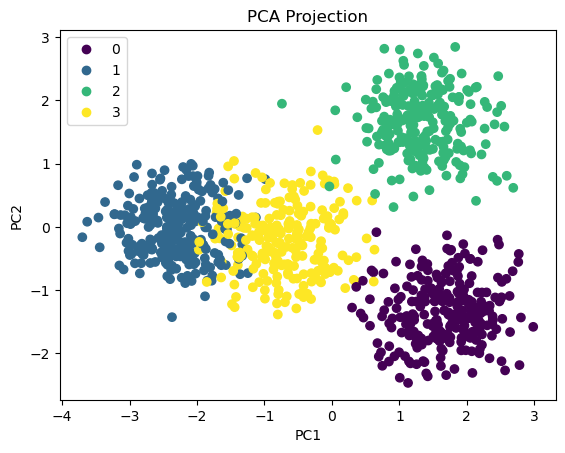

In [16]:
import matplotlib.pyplot as plt

plot = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.legend(*plot.legend_elements())
plt.show()

## TESTING

In [17]:
#testing data
df_testing = pd.read_csv("/Users/avatarvaleria/Projects/colabs/ed-prj/ed-backend/carelog/python/testing_data_scale1_6.csv")
df_test_features = df_testing.iloc[:, 1:]
print(df_test_features[:5])

   urge_intensity  binge_urge  restriction_urge  emotional_distress  \
0             4.0         3.0               9.0                10.0   
1             2.0         0.0               0.0                 1.0   
2             5.0         0.0               8.0                10.0   
3             0.0         2.0               2.0                 2.0   
4             1.0         1.0               3.0                 3.0   

   stress_level  energy_level  
0           7.0           3.0  
1           1.0           8.0  
2          10.0           5.0  
3           2.0          10.0  
4           1.0           9.0  


In [18]:
df_testing[:10]

,latent_state,urge_intensity,binge_urge,restriction_urge,emotional_distress,stress_level,energy_level
0,1,4.0,3.0,9.0,10.0,7.0,3.0
1,0,2.0,0.0,0.0,1.0,1.0,8.0
2,1,5.0,0.0,8.0,10.0,10.0,5.0
3,0,0.0,2.0,2.0,2.0,2.0,10.0
4,0,1.0,1.0,3.0,3.0,1.0,9.0
5,2,5.0,8.0,4.0,7.0,8.0,6.0
6,1,7.0,1.0,7.0,8.0,6.0,4.0
7,3,3.0,4.0,5.0,5.0,4.0,2.0
8,3,2.0,5.0,3.0,3.0,7.0,1.0
9,2,7.0,10.0,4.0,6.0,9.0,8.0


In [19]:
test_features_scaled = gmm_scaler.fit_transform(df_test_features)
print(test_features_scaled[:5])

[[-0.28251644 -0.25394595  1.4855784   1.51488328  0.4955087  -0.62526561]
 [-1.0358936  -1.19448649 -1.57396521 -1.59079998 -1.90211404  1.43152917]
 [ 0.09417215 -1.19448649  1.14562911  1.51488328  1.69432007  0.1974523 ]
 [-1.78927077 -0.56745946 -0.89406663 -1.24572406 -1.50251025  2.25424708]
 [-1.41258219 -0.88097298 -0.55411734 -0.90064814 -1.90211404  1.84288812]]


In [20]:
df_test_features["cluster_pred"] = gmm.predict(test_features_scaled)
df_test_features["state_name_pred"] = df_test_features["cluster_pred"].map(STATE_NAMES)

In [21]:
df_test_features[:10]

,urge_intensity,binge_urge,restriction_urge,emotional_distress,stress_level,energy_level,cluster_pred,state_name_pred
0,4.0,3.0,9.0,10.0,7.0,3.0,0,emotional distress + restriction
1,2.0,0.0,0.0,1.0,1.0,8.0,1,stable
2,5.0,0.0,8.0,10.0,10.0,5.0,0,emotional distress + restriction
3,0.0,2.0,2.0,2.0,2.0,10.0,1,stable
4,1.0,1.0,3.0,3.0,1.0,9.0,1,stable
5,5.0,8.0,4.0,7.0,8.0,6.0,2,emotional distress + binge/overeating
6,7.0,1.0,7.0,8.0,6.0,4.0,0,emotional distress + restriction
7,3.0,4.0,5.0,5.0,4.0,2.0,3,burnout/being numb
8,2.0,5.0,3.0,3.0,7.0,1.0,3,burnout/being numb
9,7.0,10.0,4.0,6.0,9.0,8.0,2,emotional distress + binge/overeating


In [22]:
state_original = df_testing.iloc[:, 0]
state_original

0     1
1     0
2     1
3     0
4     0
     ..
95    3
96    3
97    0
98    0
99    0
Name: latent_state, Length: 100, dtype: int64

In [23]:
df_test_features["state_original"] = state_original

In [24]:
df_test_features[:10]

,urge_intensity,binge_urge,restriction_urge,emotional_distress,stress_level,energy_level,cluster_pred,state_name_pred,state_original
0,4.0,3.0,9.0,10.0,7.0,3.0,0,emotional distress + restriction,1
1,2.0,0.0,0.0,1.0,1.0,8.0,1,stable,0
2,5.0,0.0,8.0,10.0,10.0,5.0,0,emotional distress + restriction,1
3,0.0,2.0,2.0,2.0,2.0,10.0,1,stable,0
4,1.0,1.0,3.0,3.0,1.0,9.0,1,stable,0
5,5.0,8.0,4.0,7.0,8.0,6.0,2,emotional distress + binge/overeating,2
6,7.0,1.0,7.0,8.0,6.0,4.0,0,emotional distress + restriction,1
7,3.0,4.0,5.0,5.0,4.0,2.0,3,burnout/being numb,3
8,2.0,5.0,3.0,3.0,7.0,1.0,3,burnout/being numb,3
9,7.0,10.0,4.0,6.0,9.0,8.0,2,emotional distress + binge/overeating,2


In [25]:
df_test_features["state_name_original"] = df_test_features["cluster_pred"].map(STATE_NAMES)
#state_name_original = df_features["state_name_original"]
df_test_features[:10]

,urge_intensity,binge_urge,restriction_urge,emotional_distress,stress_level,energy_level,cluster_pred,state_name_pred,state_original,state_name_original
0,4.0,3.0,9.0,10.0,7.0,3.0,0,emotional distress + restriction,1,emotional distress + restriction
1,2.0,0.0,0.0,1.0,1.0,8.0,1,stable,0,stable
2,5.0,0.0,8.0,10.0,10.0,5.0,0,emotional distress + restriction,1,emotional distress + restriction
3,0.0,2.0,2.0,2.0,2.0,10.0,1,stable,0,stable
4,1.0,1.0,3.0,3.0,1.0,9.0,1,stable,0,stable
5,5.0,8.0,4.0,7.0,8.0,6.0,2,emotional distress + binge/overeating,2,emotional distress + binge/overeating
6,7.0,1.0,7.0,8.0,6.0,4.0,0,emotional distress + restriction,1,emotional distress + restriction
7,3.0,4.0,5.0,5.0,4.0,2.0,3,burnout/being numb,3,burnout/being numb
8,2.0,5.0,3.0,3.0,7.0,1.0,3,burnout/being numb,3,burnout/being numb
9,7.0,10.0,4.0,6.0,9.0,8.0,2,emotional distress + binge/overeating,2,emotional distress + binge/overeating


In [26]:
matches = (df_test_features["state_name_pred"] == df_test_features["state_name_original"]).sum()
matches_percent = (matches/100) * 100
print(f"Percentage of matches: {matches_percent}")

Percentage of matches: 100.0


## SERIALIZING MODEL

In [28]:
import joblib

#joblib.dump(gmm, "gmm_model_tied_scaled_1_4.pkl")
joblib.dump(gmm_scaler, "scaler_gmm_tied_scaled_1_4.pkl")

['scaler_gmm_tied_scaled_1_4.pkl']